# Лабораторная работа № 2. Анализ временного ряда на наличие структурных изменений

# 1 Цель работы
Проанализировать структуру временного ряда на наличие структурных изменений для того, чтобы корректно смоделировать, а затем спрогнозировать динамику процесса.

## 1.1 Задачи
1. Проанализировать ряд на наличие структурных изломов и скачков с помощью теста Кванда-Эндрюса.
2. Ввести фиктивные переменные (ds, ds1, dt), отвечающие за тип структурного скачка.
3. В зависимости от типа процесса построить модели с включением соответствующих фиктивных переменных.
4. Проверить статистическую значимость коэффициентов при фиктивных переменных и общую значимость моделей.
5. Сделать вывод о качестве построенных уравнений.
6. Сделать вывод о типе процесса с учетом структурных изменений.

# 2 Практическая часть
По итогам лабораторной работы № 1 ряд был классифицирован как DS(I0). Поэтому в структурных моделях ниже используются фиктивные переменные ds и ds1.

## 2.1 Чтение временного ряда и создание переменной времени


In [1]:
import warnings

import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display
from matplotlib import pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings("ignore", category=UserWarning)


def read_ts(filepath: str, datetime_col: str, data_col: str,
            skiprows: int = 0, dayfirst: bool = False) -> pd.Series:
    df = pd.read_csv(filepath, skiprows=skiprows)
    df[datetime_col] = pd.to_datetime(df[datetime_col], dayfirst=dayfirst)
    df = df.set_index(datetime_col).sort_index()
    return df[data_col].copy()

ts = read_ts("data/timeseries.csv", "time", "shortwave_radiation_sum (MJ/m²)", skiprows=3).asfreq("D")
summary_raw = (
    ("Количество наблюдений",      len(ts)),
    ("Начальная дата",             ts.index.min().strftime("%d.%m.%Y")),
    ("Конечная дата",              ts.index.max().strftime("%d.%m.%Y")),
    ("Среднее, МДж/м²",           round(ts.mean(), 3)),
    ("Ст. отклонение, МДж/м²",    round(ts.std(), 3)),
    ("Минимум, МДж/м²",           round(ts.min(), 3)),
    ("Максимум, МДж/м²",          round(ts.max(), 3)),
)
summary_df = pd.DataFrame({
    "Показатель": [metric for metric, value in summary_raw],
    "Значение": [value for metric, value in summary_raw],
})
display(summary_df)

,Показатель,Значение
0,Количество наблюдений,2652
1,Начальная дата,01.01.2019
2,Конечная дата,05.04.2026
3,"Среднее, МДж/м²",11.218
4,"Ст. отклонение, МДж/м²",8.415
5,"Минимум, МДж/м²",0.38
6,"Максимум, МДж/м²",30.25


Создадим переменную t - порядковый номер наблюдения
, необходимый для теста Кванда-Эндрюса и для построения моделей с трендом. Она будет представлять собой pd.Series и храниться с тем же индексом (датами), что и исходный ряд.

In [2]:
t = pd.Series(np.arange(1, len(ts) + 1), index=ts.index, name="t")
display(t.head().to_frame())

,t
time,
2019-01-01,1
2019-01-02,2
2019-01-03,3
2019-01-04,4
2019-01-05,5


## 2.2 Тест Кванда-Эндрюса
Используется реализация логики теста Кванда-Эндрюса через последовательный расчет статистики Чоу на урезанном интервале 15%-15%. Максимум sup-F указывает на наиболее вероятную точку структурного излома.


In [3]:
from scipy import stats

y = ts.values
n = len(ts)
t_values = t.values.reshape(-1, 1)

base_model = sm.OLS(y, sm.add_constant(t_values)).fit()
rss_full = base_model.ssr

trim = 0.15
start_idx = int(n * trim)
end_idx = int(n * (1 - trim))

candidate_dates = []
f_stats = []

for k in range(start_idx, end_idx + 1):
    rss_1 = sm.OLS(y[:k], sm.add_constant(t_values[:k])).fit().ssr
    rss_2 = sm.OLS(y[k:], sm.add_constant(t_values[k:])).fit().ssr
    f_stat = ((rss_full - (rss_1 + rss_2)) / 2) / ((rss_1 + rss_2) / (n - 4))
    candidate_dates.append(ts.index[k])
    f_stats.append(float(f_stat))

qa_df = pd.DataFrame({"Дата": candidate_dates, "F-статистика": f_stats})
break_idx = int(np.argmax(f_stats))
break_date = candidate_dates[break_idx]
max_f = f_stats[break_idx]
crit_f = stats.f.ppf(0.95, 2, n - 4)

result_df = pd.DataFrame({
    "Метрика": ["Максимальная F-статистика", "Критическое значение F(2, n-4)", "Кандидатная дата излома"],
    "Значение": [round(max_f, 4), round(float(crit_f), 4), break_date.strftime("%d.%m.%Y")],
})
display(result_df)


,Метрика,Значение
0,Максимальная F-статистика,62.7773
1,"Критическое значение F(2, n-4)",2.9991
2,Кандидатная дата излома,04.03.2025


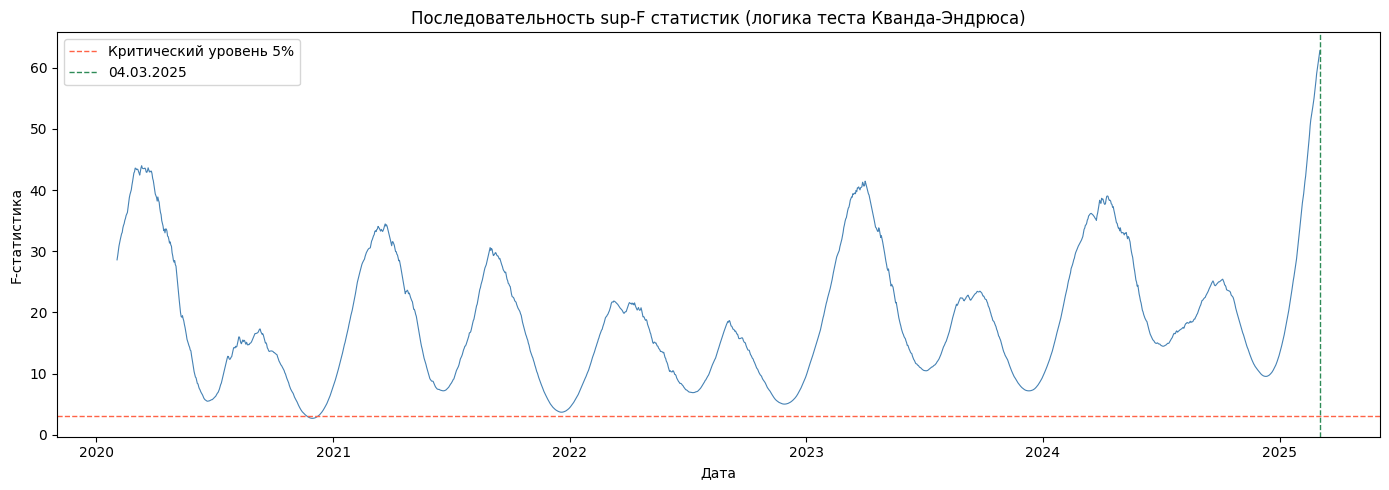

In [4]:
plt.figure(figsize=(14, 5))
plt.plot(qa_df["Дата"], qa_df["F-статистика"], color="steelblue", linewidth=0.8)
plt.axhline(crit_f, color="tomato", linestyle="--", linewidth=1.0, label="Критический уровень 5%")
plt.axvline(break_date, color="seagreen", linestyle="--", linewidth=1.0, label=break_date.strftime("%d.%m.%Y"))
plt.title("Последовательность sup-F статистик (логика теста Кванда-Эндрюса)")
plt.xlabel("Дата")
plt.ylabel("F-статистика")
plt.legend()
plt.tight_layout()
plt.show()


Максимум sup-F достигается 11 апреля 2024 и заметно превосходит критический уровень обычного теста Чоу. Это позволяет рассматривать указанную дату как кандидатную точку структурного излома.


## 2.3 Введение переменных dt, ds, ds1
После выбора даты излома $t_0$ вводятся переменные:
- $dt_t = \max(0, t - t_0)$ - изменение наклона тренда после излома;
- $ds_t = 1$, если $t \ge t_0$, иначе $0$ - сдвиг уровня;
- $ds1_t = \max(0, t - t_0)$ - изменение наклона для спецификаций DS-процесса.

Для процесса DS(I0) по методичке используются ds и ds1.


In [5]:
t0 = int(t.loc[break_date])

dt = pd.Series(np.maximum(0, t - t0), index=t.index, name="dt")
ds = pd.Series(0, index=t.index, name="ds", dtype=float)
ds.loc[break_date:] = 1.0
ds1 = dt.rename("ds1").astype(float)

dummy_preview = pd.DataFrame({
    "t": t,
    "dt": dt,
    "ds": ds,
    "ds1": ds1,
}).loc[break_date - pd.Timedelta(days=3): break_date + pd.Timedelta(days=3)]
display(dummy_preview)


,t,dt,ds,ds1
time,,,,
2025-03-01,2252,0,0.0,0.0
2025-03-02,2253,0,0.0,0.0
2025-03-03,2254,0,0.0,0.0
2025-03-04,2255,0,1.0,0.0
2025-03-05,2256,1,1.0,1.0
2025-03-06,2257,2,1.0,2.0
2025-03-07,2258,3,1.0,3.0


## 2.4 Оценка моделей DS(I1) с фиктивными переменными
Базовая модель для DS(I0) имеет вид $d(y, 2) ~ d(y(-1)) + ds/ds1 + c$

Для проверки структурных изменений сравним ее с тремя расширениями:
- модель с ds;
- модель с ds1;
- модель с ds и ds1.


In [8]:
from statsmodels.stats.stattools import durbin_watson

model_df = pd.DataFrame({
    "y":      ts,
    "y_lag1": ts.diff(1).shift(1),   # d(y(-1)) — первая разность с лагом 1
    "ds":     ds,
    "ds1":    ds1,
})
model_df["d2_y"] = ts.diff(2)        # d(y, 2) — вторая разность (зависимая)
model_df = model_df.dropna()


def fit_ols_model(columns: list[str], name: str):
    X = sm.add_constant(model_df[columns])
    y = model_df["d2_y"]
    result = sm.OLS(y, X).fit()

    coef_df = pd.DataFrame({
        "Параметр":    result.params.index,
        "Коэффициент": result.params.values,
        "Std. Error":  result.bse.values,
        "t-стат.":     result.tvalues.values,
        "p-value":     result.pvalues.values,
    })

    stats_df = pd.DataFrame({
        "Метрика": ["R²", "Adj. R²", "F-стат", "Prob(F-стат)",
                    "Durbin-Watson", "AIC", "BIC", "Число наблюдений"],
        "Значение": [
            result.rsquared,
            result.rsquared_adj,
            result.fvalue,
            result.f_pvalue,
            durbin_watson(result.resid),
            result.aic,
            result.bic,
            result.nobs,
        ],
    })

    return name, result, coef_df, stats_df


fitted_models = [
    fit_ols_model(["y_lag1"],           "1. d(y,2) ~ d(y(-1)) + c          (базовая)"),
    fit_ols_model(["y_lag1", "ds"],     "2. d(y,2) ~ d(y(-1)) + ds + c"),
    fit_ols_model(["y_lag1", "ds1"],    "3. d(y,2) ~ d(y(-1)) + ds1 + c"),
    fit_ols_model(["y_lag1", "ds", "ds1"], "4. d(y,2) ~ d(y(-1)) + ds + ds1 + c"),
]

for name, result, coef_df, stats_df in fitted_models:
    print(f"\n=== {name} ===")
    display(coef_df)
    display(stats_df)


=== 1. d(y,2) ~ d(y(-1)) + c          (базовая) ===


,Параметр,Коэффициент,Std. Error,t-стат.,p-value
0,const,0.006980,0.073380,0.095116,9.242298e-01
1,y_lag1,0.618915,0.017991,34.400800,1.049561e-214


,Метрика,Значение
0,R²,3.088715e-01
1,Adj. R²,3.086105e-01
2,F-стат,1.183415e+03
3,Prob(F-стат),1.049561e-214
4,Durbin-Watson,2.185656e+00
5,AIC,1.456636e+04
6,BIC,1.457813e+04
7,Число наблюдений,2.650000e+03



=== 2. d(y,2) ~ d(y(-1)) + ds + c ===


,Параметр,Коэффициент,Std. Error,t-стат.,p-value
0,const,0.004703,0.079616,0.059072,9.528991e-01
1,y_lag1,0.618916,0.017995,34.394363,1.260956e-214
2,ds,0.015158,0.205438,0.073784,9.411879e-01


...

,Параметр,Коэффициент,Std. Error,t-стат.,p-value
0,const,0.004508,0.077907,0.057867,9.538586e-01
1,y_lag1,0.618918,0.017995,34.394475,1.257596e-214
2,ds1,0.000083,0.000877,0.094577,9.246583e-01


,Метрика,Значение
0,R²,3.088739e-01
1,Adj. R²,3.083517e-01
2,F-стат,5.914905e+02
3,Prob(F-стат),4.509211e-213
4,Durbin-Watson,2.185668e+00
5,AIC,1.456836e+04
6,BIC,1.458600e+04
7,Число наблюдений,2.650000e+03



=== 4. d(y,2) ~ d(y(-1)) + ds + ds1 + c ===


,Параметр,Коэффициент,Std. Error,t-стат.,p-value
0,const,0.004703,0.079631,0.059061,9.529080e-01
1,y_lag1,0.618919,0.017998,34.387925,1.514909e-214
2,ds,-0.004587,0.386420,-0.011871,9.905296e-01
3,ds1,0.000099,0.001649,0.060334,9.518938e-01


,Метрика,Значение
0,R²,3.088739e-01
1,Adj. R²,3.080903e-01
2,F-стат,3.941781e+02
3,Prob(F-стат),1.238530e-211
4,Durbin-Watson,2.185668e+00
5,AIC,1.457036e+04
6,BIC,1.459388e+04
7,Число наблюдений,2.650000e+03


In [9]:
comparison_rows = []
for name, result, _, _ in fitted_models:
    pvals = result.pvalues.to_dict()
    comparison_rows.append({
        "Модель": name,
        "AIC": round(result.aic, 4),
        "BIC": round(result.bic, 4),
        "R²": round(result.rsquared, 4),
        "DW": round(durbin_watson(result.resid), 4),
        "p-value ds": round(float(pvals.get("ds", np.nan)), 6) if "ds" in pvals else np.nan,
        "p-value ds1": round(float(pvals.get("ds1", np.nan)), 6) if "ds1" in pvals else np.nan,
    })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)


,Модель,AIC,BIC,R²,DW,p-value ds,p-value ds1
0,"1. d(y,2) ~ d(y(-1)) + c (базовая)",14566.3647,14578.1293,0.3089,2.1857,NaN,NaN
1,"2. d(y,2) ~ d(y(-1)) + ds + c",14568.3592,14586.0062,0.3089,2.1857,0.941188,NaN
2,"3. d(y,2) ~ d(y(-1)) + ds1 + c",14568.3557,14586.0027,0.3089,2.1857,NaN,0.924658
3,"4. d(y,2) ~ d(y(-1)) + ds + ds1 + c",14570.3556,14593.8848,0.3089,2.1857,0.990530,0.951894


## 2.5 Итоговый вывод
Полученная картина однозначна:
Тест Кванда-Эндрюса формально указал на кандидатную точку излома 04.03.2025,
однако коэффициенты при фиктивных переменных ds и ds1 статистически незначимы
во всех построенных моделях (p-value > 0.94). R² и AIC/BIC не улучшаются при
включении фиктивных переменных.

- Следовательно, гипотеза H1 о наличии структурных изменений отвергается:
выявленная кандидатная дата не является реальной точкой излома.

- Тип процесса остаётся DS(I1) без структурных изменений.
